# Dynamical Friction Tutorial

**Chandrasekhar dynamical friction with `nbody_streams`**

Four runs comparing orbital evolution with and without DF:

| Run | Satellite | DF? |
|-----|-----------|-----|
| A-noDF | 5×10⁹ M☉ | ✗ (reference) |
| A-DF   | 5×10⁹ M☉ | ✓ |
| B-noDF | 10⁷ M☉   | ✗ |
| B-DF   | 10⁷ M☉   | ✓ (should match B-noDF) |


## 1. Imports

In [17]:
import os
import numpy as np
import matplotlib.pyplot as plt
import agama

agama.setUnits(mass=1, length=1, velocity=1)

import nbody_streams as nb
from nbody_streams import run_simulation, Species, make_plummer_sphere, ParticleReader
from nbody_streams.utils import iterative_unbinding, find_center

# Time-unit conversion: 1 kpc/(km/s) = 0.9778 Gyr
KPC_KMS_TO_GYR = 0.9778

print('nbody_streams version:', nb.__version__)
print('Agama version:', agama.__version__)


nbody_streams version: 2.2.0
Agama version: 1.0.156 compiled on Jan 27 2026


## 2. Host potential

NFW-like Spheroid (M = 10¹² M☉, r_s = 15 kpc, outer cut-off at 300 kpc).
`cutoffStrength=2` gives a softer outer truncation that preserves a realistic
density profile at 40 kpc.


In [18]:
pot_host = agama.Potential(
    type='Spheroid',
    mass=1e12,
    scaleRadius=15.0,
    outerCutoffRadius=300.0,
    gamma=1, beta=3, cutoffStrength=2,
)

R0 = 40.0   # initial galactocentric radius [kpc]
v_circ_R0 = float(np.sqrt(R0 * abs(pot_host.force([R0, 0., 0.])[0])))
print(f'v_circ(R0={R0} kpc) = {v_circ_R0:.1f} km/s')


v_circ(R0=40.0 kpc) = 181.2 km/s


## 3. Expected DF inspiral timescales

From Binney & Tremaine (2008) eq. 8.13, for a satellite on a circular orbit at radius $r_0$ in an isothermal-sphere-like halo with circular speed $v_c$:

$$
t_{\rm DF} \approx \frac{1.17}{\ln\Lambda} \frac{r_0^2\, v_c}{G\, M_{\rm sat}}
$$

with Coulomb logarithm $\ln\Lambda \approx \ln(r_0 v_c^2 / G M_{\rm sat})$.


In [19]:
G_nbody = 4.300917e-6   # kpc (km/s)^2 Msun^-1

def t_df_estimate(M_sat, r0, v_c):
    ln_lam = np.log(r0 * v_c**2 / (G_nbody * M_sat))
    t_kpc  = 1.17 / ln_lam * r0**2 * v_c / (G_nbody * M_sat)
    return t_kpc * KPC_KMS_TO_GYR, ln_lam

for M_sat, name in [(5e9, 'Sat A (5e9 Msun)'), (1e7, 'Sat B (1e7 Msun)')]:
    t_gyr, ln_l = t_df_estimate(M_sat, R0, v_circ_R0)
    print(f'{name:25s}  ln(Λ) = {ln_l:.2f}  t_DF ≈ {t_gyr:.1f} Gyr')


Sat A (5e9 Msun)           ln(Λ) = 4.11  t_DF ≈ 3.8 Gyr
Sat B (1e7 Msun)           ln(Λ) = 10.33  t_DF ≈ 746.7 Gyr


## 4. Satellite initial conditions

### Satellite A — 5×10⁹ M☉
Plummer sphere, a = 1.0 kpc, ε = 0.05 kpc.  t_DF ~ 3 Gyr → partial inspiral, stream formation expected.

### Satellite B — 10⁷ M☉
Plummer sphere, a = 0.3 kpc, ε = 0.02 kpc.  t_DF >> 1000 Gyr → DF contribution negligible even when enabled.


In [20]:
N_SAT = 50_000

# ── Satellite A ──────────────────────────────────────────────────────────────
M_A      = 5e9
a_A      = 1.0
eps_A    = 0.05
m_part_A = M_A / N_SAT   # 1e5 Msun per particle

xv_plt_A, _ = make_plummer_sphere(N_SAT, M_total=M_A, a=a_A)
xv_A = xv_plt_A.copy()
xv_A[:, 0] += R0
xv_A[:, 4] += v_circ_R0
dm_A = Species.dark(N=N_SAT, mass=m_part_A, softening=eps_A)

# ── Satellite B ──────────────────────────────────────────────────────────────
M_B      = 1e7
a_B      = 0.3
eps_B    = 0.02
m_part_B = M_B / N_SAT   # 200 Msun per particle

xv_plt_B, _ = make_plummer_sphere(N_SAT, M_total=M_B, a=a_B)
xv_B = xv_plt_B.copy()
xv_B[:, 0] += R0
xv_B[:, 4] += v_circ_R0
dm_B = Species.dark(N=N_SAT, mass=m_part_B, softening=eps_B)

masses_A = np.full(N_SAT, m_part_A)
masses_B = np.full(N_SAT, m_part_B)

print(f'Sat A: M={M_A:.0e}  m_part={m_part_A:.0e}  a={a_A} kpc  eps={eps_A} kpc')
print(f'Sat B: M={M_B:.0e}  m_part={m_part_B:.0e}  a={a_B} kpc  eps={eps_B} kpc')


Sat A: M=5e+09  m_part=1e+05  a=1.0 kpc  eps=0.05 kpc
Sat B: M=1e+07  m_part=2e+02  a=0.3 kpc  eps=0.02 kpc


## 5. Integration parameters

In [21]:
T_END   = 3.07   # kpc/(km/s)  ≈ 3.0 Gyr
DT      = 5e-4   # kpc/(km/s)  ≈ 0.5 Myr  →  ~6140 steps
N_SNAPS = 100    # one snapshot every ~30 Myr

print(f'Integration: {T_END / DT:.0f} steps, {T_END * KPC_KMS_TO_GYR:.2f} Gyr')
print(f'Snapshot cadence: {T_END / N_SNAPS * KPC_KMS_TO_GYR * 1e3:.0f} Myr')


Integration: 6140 steps, 3.00 Gyr
Snapshot cadence: 30 Myr


## 6. Run Satellite A — no DF (reference orbit)

In [22]:
OUT_A_NODF = './output/sat_A_noDF'

print('Sat A  [no DF] ...')
result_A_noDF = run_simulation(
    xv_A, [dm_A], time_start=0.0, time_end=T_END, dt=DT,
    architecture='gpu', method='direct',
    external_potential=pot_host, dynamical_friction=False,
    output_dir=OUT_A_NODF, save_snapshots=True, snapshots=N_SNAPS,
    overwrite=True, verbose=False,
)
final_A_noDF = result_A_noDF['dark']
print(f'Shape: {final_A_noDF.shape}')


Sat A  [no DF] ...
Shape: (50000, 6)


## 7. Run Satellite A — with DF

GPU direct path: `phi` not returned → **fallback** shrinking-sphere CoM + `df_apply_radius_factor=2.0` to exclude stripped debris from feeling DF.
M_sat is fixed (no dynamic mass loss on this path).  Switch to `method='tree'` for phi-based dynamic M_bound.


In [23]:
OUT_A_DF = './output/sat_A_DF'

print('Sat A  [WITH DF] ...')
result_A_DF = run_simulation(
    xv_A, [dm_A], time_start=0.0, time_end=T_END, dt=DT,
    architecture='gpu', method='direct',
    external_potential=pot_host, dynamical_friction=True,
    df_M_sat=M_A, df_coulomb_mode='variable',
    df_apply_radius_factor=2.0, df_sigma_method='jeans',
    output_dir=OUT_A_DF, save_snapshots=True, snapshots=N_SNAPS,
    overwrite=True, verbose=False,
)
final_A_DF = result_A_DF['dark']
print(f'Shape: {final_A_DF.shape}')


Sat A  [WITH DF] ...
Shape: (50000, 6)


## 8. Run Satellite B — no DF

In [24]:
OUT_B_NODF = './output/sat_B_noDF'

print('Sat B  [no DF] ...')
result_B_noDF = run_simulation(
    xv_B, [dm_B], time_start=0.0, time_end=T_END, dt=DT,
    architecture='gpu', method='direct',
    external_potential=pot_host, dynamical_friction=False,
    output_dir=OUT_B_NODF, save_snapshots=True, snapshots=N_SNAPS,
    overwrite=True, verbose=False,
)
final_B_noDF = result_B_noDF['dark']
print(f'Shape: {final_B_noDF.shape}')


Sat B  [no DF] ...
Shape: (50000, 6)


## 9. Run Satellite B — with DF

At 10⁷ M☉ the DF acceleration is ~500× weaker than Sat A.  This run should be **visually indistinguishable** from the no-DF control, demonstrating that the code correctly scales with mass.


In [25]:
OUT_B_DF = './output/sat_B_DF'

print('Sat B  [WITH DF] ...')
result_B_DF = run_simulation(
    xv_B, [dm_B], time_start=0.0, time_end=T_END, dt=DT,
    architecture='gpu', method='direct',
    external_potential=pot_host, dynamical_friction=True,
    df_M_sat=M_B, df_coulomb_mode='variable',
    df_apply_radius_factor=2.0, df_sigma_method='jeans',
    output_dir=OUT_B_DF, save_snapshots=True, snapshots=N_SNAPS,
    overwrite=True, verbose=False,
)
final_B_DF = result_B_DF['dark']
print(f'Shape: {final_B_DF.shape}')


Sat B  [WITH DF] ...
Shape: (50000, 6)


## 10. Time-series analysis

For each snapshot we compute:

- **CoM radius**: `find_center(method='density_peak')` — gravitational potential
  minimum of the surviving core, robust to tidal debris.
- **Bound fraction**: `iterative_unbinding` every 5th snapshot (~150 Myr cadence).

> **On the CoM jitter in the no-DF run**: the r_com(t) curve for Sat A without DF
> will not be perfectly flat even on a circular orbit.  This is partly real
> (the self-gravity of the satellite perturbs its CoM through dynamical friction
> on the host's own field stars — but those aren't modelled here as particles),
> partly the density-peak finder returning slightly different centers step-to-step
> as the outer halo particles shift.  The jitter shrinks as N increases.


In [28]:
def load_time_series(output_dir, masses_arr, eps, bound_every=5):
    """Return (times, r_com, fb_times, fb_vals) from a snapshot directory."""
    import glob
    pattern = os.path.join(output_dir, 'snapshot.h5')
    reader  = ParticleReader(pattern, verbose=False)
    snaps   = reader.Snapshots

    times, r_com, fb_times, fb_vals = [], [], [], []

    for i, s in enumerate(snaps):
        part = reader.read_snapshot(s)
        xv   = part.dark['posvel']
        t    = reader._snap_to_time_map.get(s, np.nan)
        pos  = xv[:, :3];  vel = xv[:, 3:6]

        centre = find_center(pos, mass=masses_arr, method='density_peak')
        times.append(t * KPC_KMS_TO_GYR)
        r_com.append(float(np.linalg.norm(centre)))

        if i % bound_every == 0:
            res = iterative_unbinding(
                pos_dark=pos, vel_dark=vel, mass_dark=masses_arr,
                potential_compute_method='tree', softening=float(eps), verbose=False,
            )
            fb_times.append(t * KPC_KMS_TO_GYR)
            fb_vals.append(float(res[0][0].sum()) / len(masses_arr))

    return np.array(times), np.array(r_com), np.array(fb_times), np.array(fb_vals)


print('Processing snapshots (this takes a few minutes) ...')
t_An, rc_An, fbt_An, fb_An = load_time_series(OUT_A_NODF, masses_A, eps_A)
t_Ad, rc_Ad, fbt_Ad, fb_Ad = load_time_series(OUT_A_DF,   masses_A, eps_A)
t_Bn, rc_Bn, fbt_Bn, fb_Bn = load_time_series(OUT_B_NODF, masses_B, eps_B)
t_Bd, rc_Bd, fbt_Bd, fb_Bd = load_time_series(OUT_B_DF,   masses_B, eps_B)
print('Done.')


Processing snapshots (this takes a few minutes) ...
Done.


## 11. Final snapshot — density maps

Using SPH surface-density rendering (`viz.plot_density`).

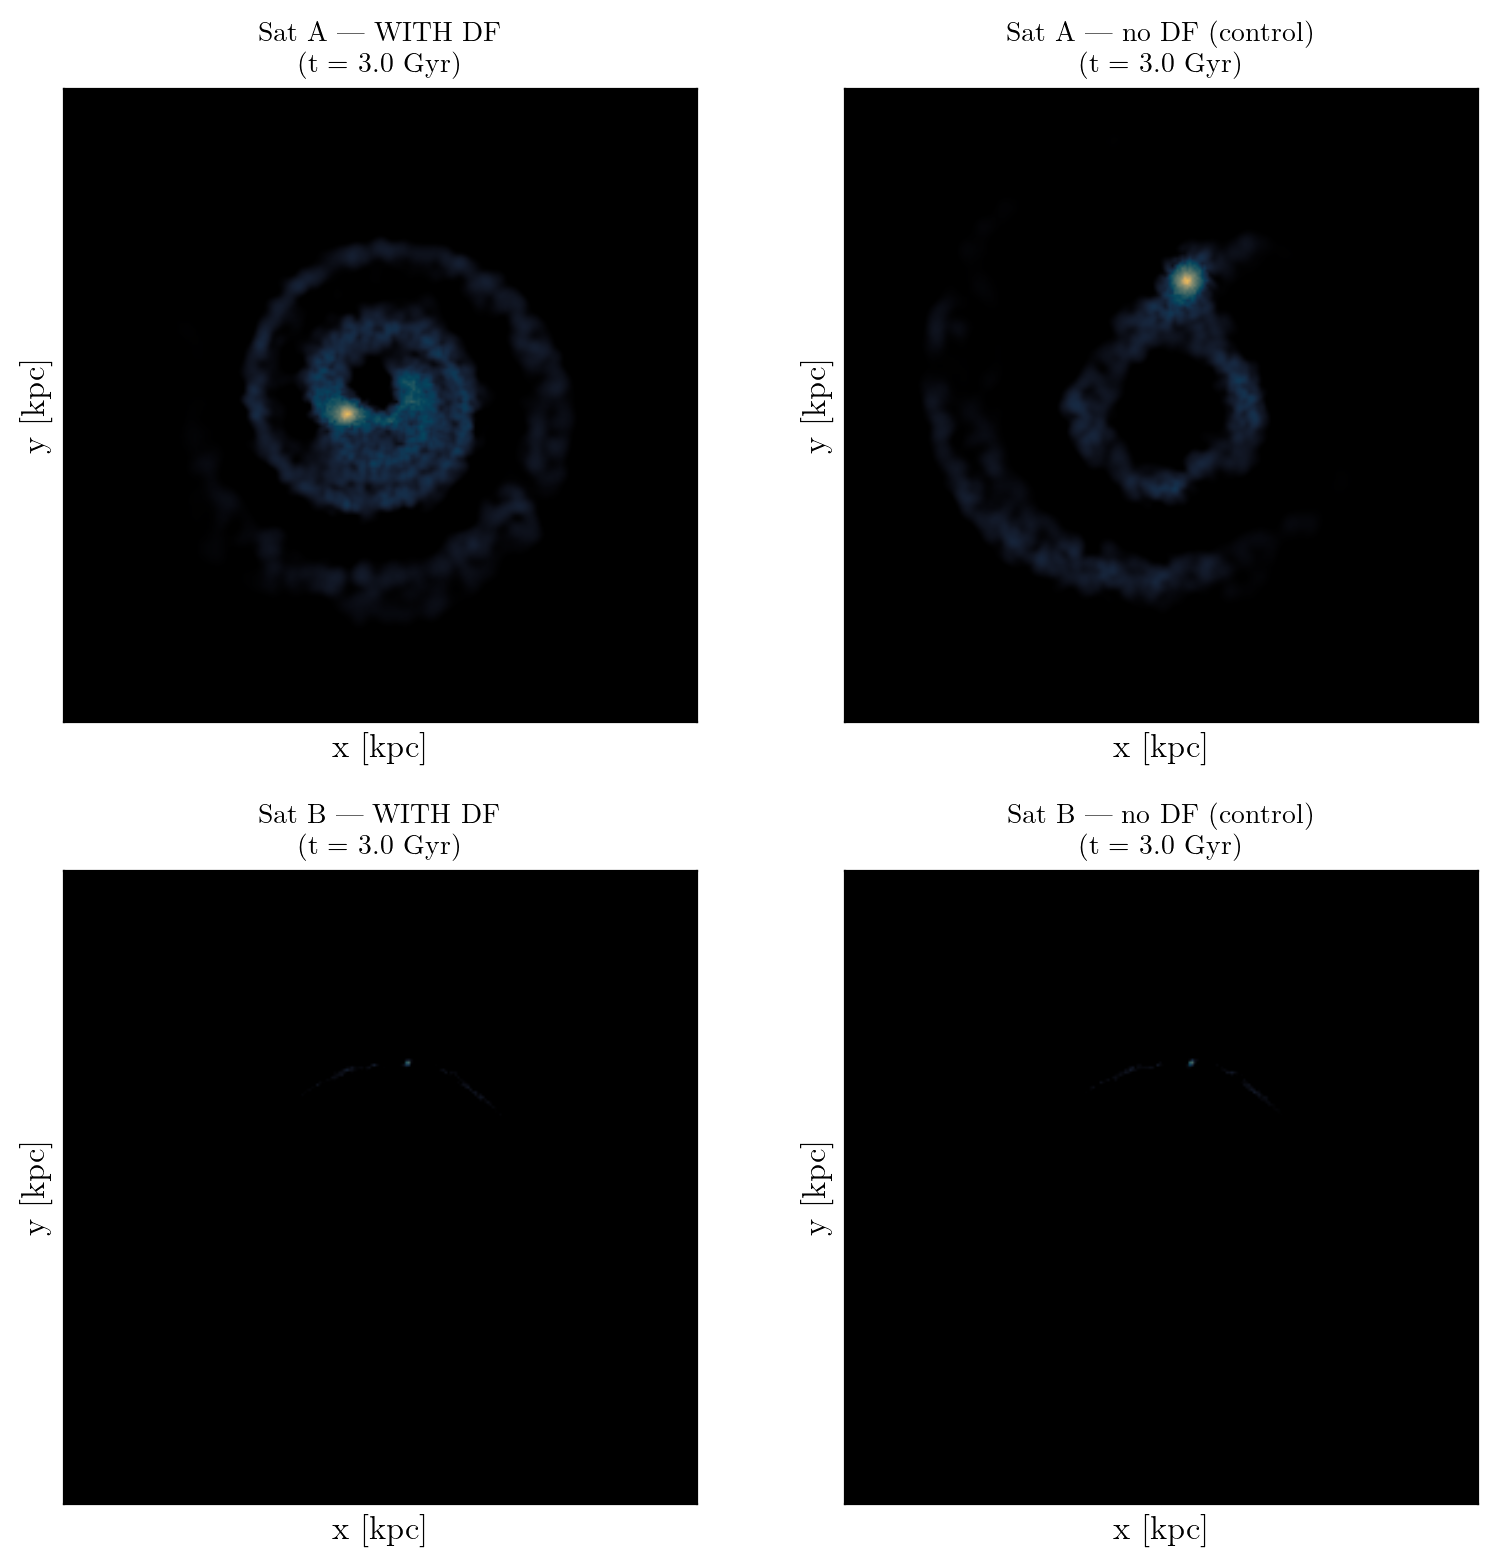

In [29]:
# Convenience aliases for the density plotter
t_final = T_END

pos_A_df_final    = final_A_DF[:, :3]
mass_A_df_final   = masses_A
pos_A_nodf_final  = final_A_noDF[:, :3]
mass_A_nodf_final = masses_A
pos_B_df_final    = final_B_DF[:, :3]
mass_B_df_final   = masses_B
pos_B_nodf_final  = final_B_noDF[:, :3]
mass_B_nodf_final = masses_B

fig, axes = plt.subplots(2, 2, figsize=(8, 8), dpi=200)

panels = [
    (axes[0, 0], pos_A_df_final,   mass_A_df_final,
     f'Sat A — WITH DF\n(t = {t_final * KPC_KMS_TO_GYR:.1f} Gyr)'),
    (axes[0, 1], pos_A_nodf_final, mass_A_nodf_final,
     f'Sat A — no DF (control)\n(t = {t_final * KPC_KMS_TO_GYR:.1f} Gyr)'),
    (axes[1, 0], pos_B_df_final,   mass_B_df_final,
     f'Sat B — WITH DF\n(t = {t_final * KPC_KMS_TO_GYR:.1f} Gyr)'),
    (axes[1, 1], pos_B_nodf_final, mass_B_nodf_final,
     f'Sat B — no DF (control)\n(t = {t_final * KPC_KMS_TO_GYR:.1f} Gyr)'),
]

for ax, pos, mass, title in panels:
    nb.viz.plot_density(
        pos=pos, mass=mass, ax=ax,
        xval='X', yval='Y',
        method='sph',
        gridsize=200.0,
        vmin=4, vmax=10,
        resolution=256,
        return_dens=False,
    )
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('x [kpc]')
    ax.set_ylabel('y [kpc]')

plt.tight_layout()
os.makedirs('./output', exist_ok=True)
plt.savefig('./output/final_density_2x2.png', dpi=150, bbox_inches='tight')
plt.show()


## 12. CoM galactocentric radius vs time

Sat A with DF spirals inward; Sat A no DF stays near 40 kpc (with small jitter — see §10 note).  Sat B with and without DF should overplot almost exactly.


(0.0, 41.48570657655418)

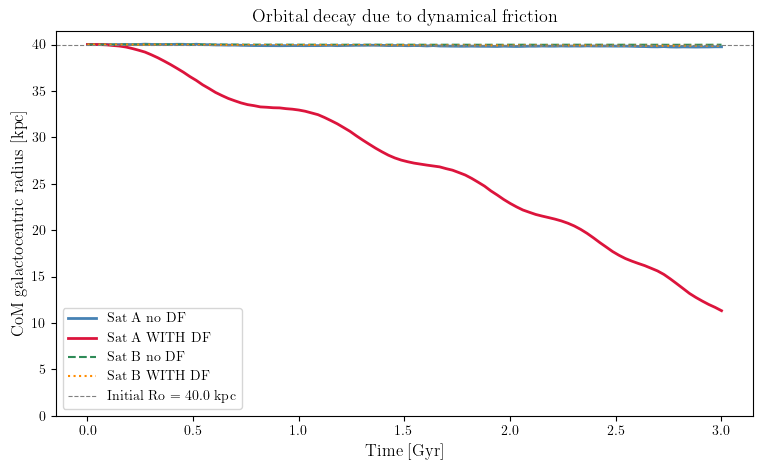

In [35]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(t_An, rc_An, color='steelblue', lw=2.0,  ls='-',  label='Sat A  no DF')
ax.plot(t_Ad, rc_Ad, color='crimson',   lw=2.0,  ls='-',  label='Sat A  WITH DF')
ax.plot(t_Bn, rc_Bn, color='seagreen',  lw=1.5,  ls='--', label='Sat B  no DF')
ax.plot(t_Bd, rc_Bd, color='darkorange',lw=1.5,  ls=':',  label='Sat B  WITH DF')

ax.axhline(R0, ls='--', color='gray', lw=0.8, label=f'Initial Ro = {R0} kpc')
ax.set_xlabel('Time [Gyr]', fontsize=12)
ax.set_ylabel('CoM galactocentric radius [kpc]', fontsize=12)
ax.set_title('Orbital decay due to dynamical friction', fontsize=13)
ax.legend(fontsize=10)
ax.set_ylim(bottom=0)
# plt.show()


## 13. Bound fraction vs time

With DF, Sat A reaches smaller pericentric radii where the tidal field is stronger — mass stripping accelerates.  Sat B should show nearly identical bound fractions with and without DF.


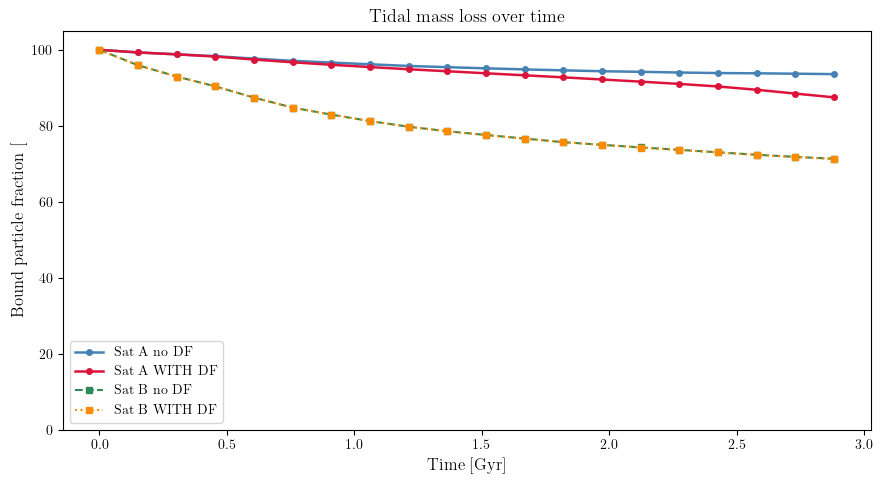

In [34]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(fbt_An, fb_An*100, 'o-', color='steelblue',  lw=1.8, ms=4, label='Sat A  no DF')
ax.plot(fbt_Ad, fb_Ad*100, 'o-', color='crimson',    lw=1.8, ms=4, label='Sat A  WITH DF')
ax.plot(fbt_Bn, fb_Bn*100, 's--',color='seagreen',   lw=1.5, ms=4, label='Sat B  no DF')
ax.plot(fbt_Bd, fb_Bd*100, 's:', color='darkorange',  lw=1.5, ms=4, label='Sat B  WITH DF')

ax.set_xlabel('Time [Gyr]', fontsize=12)
ax.set_ylabel('Bound particle fraction [%]', fontsize=12)
ax.set_title('Tidal mass loss over time', fontsize=13)
ax.legend(fontsize=10)
ax.set_ylim(0, 105)
plt.tight_layout()
plt.savefig('./output/bound_fraction_vs_time.png', dpi=150)
plt.show()


## 14. Quick-reference: DF kwargs

```python
run_simulation(
    xv, species, t_start, t_end, dt,
    external_potential=pot_host,
    dynamical_friction=True,
    df_M_sat=5e9,               # satellite mass [Msun]
    df_coulomb_mode='variable', # 'variable' ln(rv²/GM) or 'fixed'
    df_fixed_ln_lambda=3.0,     # only when coulomb_mode='fixed'
    df_sigma_method='jeans',    # 'jeans' | 'local_circular' | 'quasispherical'
    df_apply_radius_factor=2.0, # direct path: DF within 2×r_sphere of CoM
    df_update_interval=10,      # recalculate CoM every N steps
    df_core_gamma=0.0,          # core-stalling suppression index
    df_r_core=1.0,              # core radius [kpc]
)
```

**Tree vs direct paths:**

| Backend | phi returned? | CoM method | M_sat in formula |
|---------|:---:|-----------|----------|
| CPU/GPU tree | ✓ free | energy-based (φ+½v²<0) | dynamic M_bound |
| GPU/CPU direct | ✗ | shrinking sphere | fixed df_M_sat |
